# SciBERT — Entrenamiento del modelo de clasificación retórica

Notebook para entrenar y almacenar modelo con mejores metricas. Entrena la **Variante 1 (baseline sin downsampling)** de `allenai/scibert_scivocab_cased` sobre `armanc/pubmed-rct20k` y guarda el modelo y el tokenizador en `./model/scibert_pubmed/` archivos que se dejan listos para ser usados por el backend FastAPI del microproyecto

Aporte por Edwin Cifuentes

**Hiperparámetros:**
- `learning_rate = 2e-5`
- `batch_size = 128`
- `num_epochs = 5`
- `max_length = 128`
- `fp16 = True` (requiere GPU con soporte CUDA)
- `use_downsampling = False` (dataset completo)

In [1]:
# ── 1. Dependencias ────────────────────────────────────────────────────────
import subprocess, sys

packages = ['datasets', 'transformers', 'torch', 'scikit-learn', 'accelerate', 'seaborn', 'matplotlib']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✓ {pkg} installed')

  ✓ datasets
  ✓ transformers
  ✓ torch
  installing scikit-learn...
  ✓ scikit-learn installed
  ✓ accelerate
  ✓ seaborn
  ✓ matplotlib


In [2]:
# ── 2. Imports ─────────────────────────────────────────────────────────────
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from datasets import load_dataset
from sklearn.metrics import (
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠ No GPU detected — entrenamiento será muy lento. Se recomienda usar Colab/Kaggle con T4 o A100.')

Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# ── 3. Configuración ───────────────────────────────────────────────────────
MODEL_NAME  = 'allenai/scibert_scivocab_cased'
OUTPUT_DIR  = Path('./model/scibert_pubmed')   # <-- aquí queda el modelo final
RESULTS_DIR = Path('./results/scibert')

# Hiperparámetros — Variant 1 Baseline (matriz de confusión de referencia)
LEARNING_RATE = 2e-5
BATCH_SIZE    = 128     # se podria reducir a 32 si hay OOM en GPU
NUM_EPOCHS    = 5
MAX_LENGTH    = 128
FP16          = torch.cuda.is_available()   # True solo si hay GPU
WEIGHT_DECAY  = 0.01
SEED          = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Model output: {OUTPUT_DIR.resolve()}')

Model output: /content/model/scibert_pubmed


In [4]:
# ── 4. Dataset ─────────────────────────────────────────────────────────────
print('Loading armanc/pubmed-rct20k ...')
train_dataset = load_dataset('armanc/pubmed-rct20k', split='train')
val_dataset   = load_dataset('armanc/pubmed-rct20k', split='validation')
test_dataset  = load_dataset('armanc/pubmed-rct20k', split='test')

print(f'Train:      {len(train_dataset):,}')
print(f'Validation: {len(val_dataset):,}')
print(f'Test:       {len(test_dataset):,}')

# Label mapping (orden alfabético = reproducible)
unique_labels = sorted(set(train_dataset['label']))
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label  = {idx: label for label, idx in label2id.items()}
num_labels = len(unique_labels)

print(f'\nLabels ({num_labels}):')
for label, idx in label2id.items():
    print(f'  {idx}: {label}')

Loading armanc/pubmed-rct20k ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.
Repo card metadata block was not found. Setting CardData to empty.


Train:      176,642
Validation: 29,672
Test:       29,578

Labels (5):
  0: background
  1: conclusions
  2: methods
  3: objective
  4: results


In [5]:
# ── 5. Dataset PyTorch ─────────────────────────────────────────────────────
class SentenceLevelDataset(Dataset):
    """Wrapper PyTorch Dataset sobre el HuggingFace dataset."""

    def __init__(self, hf_dataset, tokenizer, max_length=128):
        self.dataset    = hf_dataset
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        example  = self.dataset[idx]
        text     = example['text']
        label    = example['label']
        label_id = label2id[label] if isinstance(label, str) else label

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
        )
        return {
            'input_ids':      encoding['input_ids'],
            'attention_mask': encoding['attention_mask'],
            'labels':         label_id,
        }

In [6]:
# ── 6. Métricas ────────────────────────────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    macro_f1 = f1_score(labels, predictions, average='macro')
    micro_f1 = f1_score(labels, predictions, average='micro')

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average=None, labels=range(num_labels)
    )
    metrics = {'macro_f1': macro_f1, 'micro_f1': micro_f1}
    for idx, name in id2label.items():
        if idx < len(f1):
            metrics[f'precision_{name}'] = precision[idx]
            metrics[f'f1_{name}']        = f1[idx]
    return metrics

In [7]:
# ── 7. Tokenizador y modelo ────────────────────────────────────────────────
print(f'Loading tokenizer and model: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
)
print(f'Parameters: {model.num_parameters():,}')

Loading tokenizer and model: allenai/scibert_scivocab_cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newl

Parameters: 109,942,277


In [8]:
# ── 8. PyTorch datasets ────────────────────────────────────────────────────
train_ds = SentenceLevelDataset(train_dataset, tokenizer, MAX_LENGTH)
val_ds   = SentenceLevelDataset(val_dataset,   tokenizer, MAX_LENGTH)
test_ds  = SentenceLevelDataset(test_dataset,  tokenizer, MAX_LENGTH)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f'Train ds:  {len(train_ds):,}')
print(f'Val ds:    {len(val_ds):,}')
print(f'Test ds:   {len(test_ds):,}')

Train ds:  176,642
Val ds:    29,672
Test ds:   29,578


In [9]:
# ── 9. Entrenamiento ───────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir=str(RESULTS_DIR),
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    greater_is_better=True,
    push_to_hub=False,
    logging_steps=100,
    report_to=['none'],
    save_total_limit=1,          # conservar solo el mejor checkpoint
    fp16=FP16,
    dataloader_num_workers=2 if torch.cuda.is_available() else 0,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print('Starting training...')
train_result = trainer.train()
print(f'\nTrain loss:   {train_result.training_loss:.4f}')
print(f'Train runtime: {train_result.metrics["train_runtime"]:.0f}s')

Starting training...


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Precision Background,F1 Background,Precision Conclusions,F1 Conclusions,Precision Methods,F1 Methods,Precision Objective,F1 Objective,Precision Results,F1 Results
1,0.346117,0.315738,0.822715,0.883729,0.663808,0.711907,0.855563,0.858262,0.942178,0.949322,0.772067,0.663466,0.933088,0.930616
2,0.293305,0.329157,0.815537,0.879718,0.606593,0.712046,0.887026,0.839503,0.939492,0.951104,0.827267,0.643170,0.939022,0.931859
3,0.250132,0.329305,0.825686,0.885414,0.660435,0.727301,0.848562,0.858898,0.942642,0.950349,0.814382,0.662003,0.938885,0.929879
4,0.209618,0.354332,0.821647,0.880628,0.659312,0.708729,0.858285,0.850727,0.941900,0.948388,0.740909,0.673554,0.933333,0.926839
5,0.181173,0.374342,0.820446,0.879112,0.654670,0.713352,0.853890,0.848452,0.945195,0.947611,0.748956,0.668686,0.929305,0.924130


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 116, in auto_conversion
    raise e
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 95, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 71, in get_conversion_pr_reference
    spawn_conversion(token, private, model_id)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_conversion.py", line 47, in spawn_con

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Train loss:   0.2644
Train runtime: 614s


In [10]:
# ── 10. Evaluación en test set ─────────────────────────────────────────────
print('Evaluating on test set...')
predictions = trainer.predict(test_ds)
y_pred = predictions.predictions.argmax(axis=-1)
y_true = predictions.label_ids

label_names = [id2label[i] for i in range(num_labels)]

report = classification_report(y_true, y_pred, target_names=label_names, digits=4)
print('\nClassification Report:')
print(report)

# Guardar reporte
report_path = RESULTS_DIR / 'classification_report.txt'
report_path.write_text(report)
print(f'Report saved → {report_path}')

Evaluating on test set...



Classification Report:
              precision    recall  f1-score   support

  background     0.6530    0.7914    0.7155      3077
 conclusions     0.8344    0.8578    0.8460      4571
     methods     0.9299    0.9550    0.9423      9884
   objective     0.7807    0.5294    0.6309      2333
     results     0.9363    0.9078    0.9218      9713

    accuracy                         0.8739     29578
   macro avg     0.8268    0.8082    0.8113     29578
weighted avg     0.8767    0.8739    0.8725     29578

Report saved → results/scibert/classification_report.txt


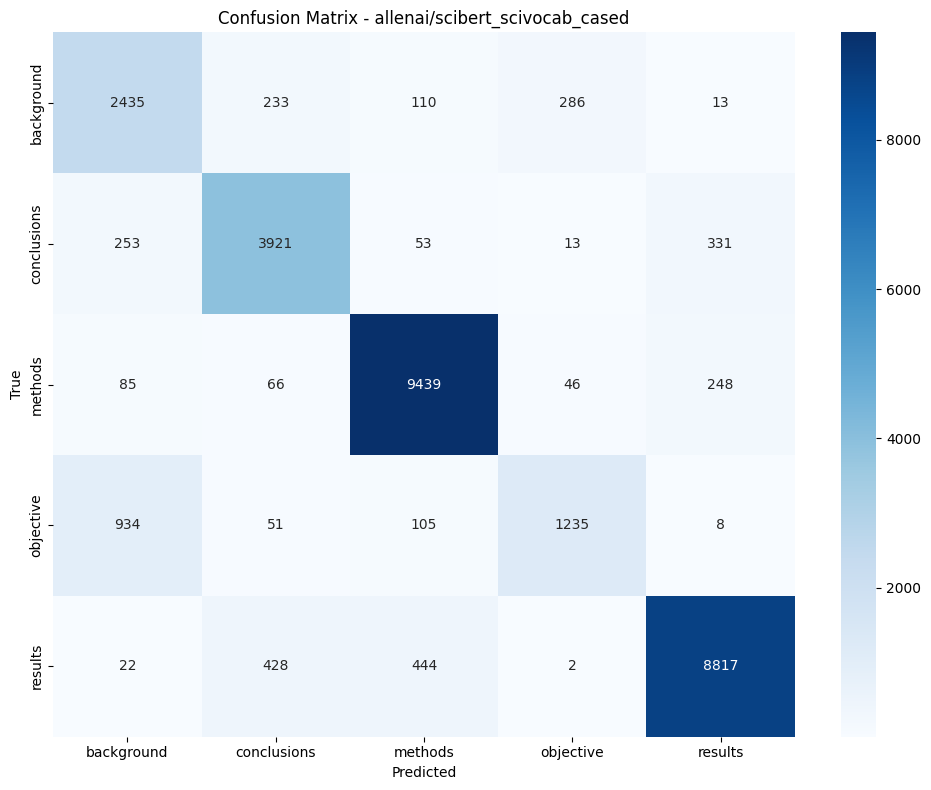

Confusion matrix saved → results/scibert/confusion_matrix.png


In [11]:
# ── 11. Matriz de confusión ────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix - {MODEL_NAME}')
plt.tight_layout()

cm_path = RESULTS_DIR / 'confusion_matrix.png'
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Confusion matrix saved → {cm_path}')

In [12]:
# ── 12. Guardar modelo y tokenizador ──────────────────────────────────────
#
# Estructura de salida en OUTPUT_DIR:
#   model/scibert_pubmed/
#     config.json          ← arquitectura + label2id / id2label
#     tokenizer_config.json
#     tokenizer.json
#     vocab.txt
#     pytorch_model.bin    ← pesos (o model.safetensors)
#     label_meta.json      ← copia explícita del mapping para el backend
#
import json

trainer.save_model(str(OUTPUT_DIR))
tokenizer.save_pretrained(str(OUTPUT_DIR))

# Guardar label mapping de forma explícita para que el backend lo lea
# sin depender de config.json de HuggingFace
label_meta = {
    'label2id': label2id,
    'id2label':  {str(k): v for k, v in id2label.items()},
    'num_labels': num_labels,
    'model_name': MODEL_NAME,
}
(OUTPUT_DIR / 'label_meta.json').write_text(json.dumps(label_meta, indent=2))

print(f'\n✓ Modelo guardado en: {OUTPUT_DIR.resolve()}')
print('Archivos:')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Modelo guardado en: /content/model/scibert_pubmed
Archivos:
  config.json  (0.0 MB)
  label_meta.json  (0.0 MB)
  model.safetensors  (439.8 MB)
  tokenizer.json  (0.7 MB)
  tokenizer_config.json  (0.0 MB)
  training_args.bin  (0.0 MB)


In [13]:
# ── 13. Smoke test del modelo guardado ────────────────────────────────────
# Verifica que el modelo guardado produce el output correcto antes de
# integrarlo al backend.
from transformers import pipeline

pipe = pipeline(
    'text-classification',
    model=str(OUTPUT_DIR),
    tokenizer=str(OUTPUT_DIR),
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=MAX_LENGTH,
)

test_sentences = [
    'This study aims to evaluate whether digital coaching improves blood pressure control.',
    'We conducted a randomized controlled trial enrolling 240 participants.',
    'We found a significant reduction in mean systolic blood pressure (-8.6 mmHg vs -2.1 mmHg).',
    'These findings suggest that scalable digital coaching can improve cardiovascular outcomes.',
    'Hypertension is one of the most important modifiable risk factors worldwide.',
]

print('Smoke test — clasificación de oraciones:')
print('-' * 70)
for sent in test_sentences:
    result = pipe(sent)[0]
    print(f'  [{result["label"]:12s}  {result["score"]:.3f}]  {sent[:65]}...')
print('\n✓ Modelo listo para integrar al backend.')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Smoke test — clasificación de oraciones:
----------------------------------------------------------------------
  [objective     0.572]  This study aims to evaluate whether digital coaching improves blo...
  [methods       0.984]  We conducted a randomized controlled trial enrolling 240 particip...
  [results       0.995]  We found a significant reduction in mean systolic blood pressure ...
  [conclusions   0.997]  These findings suggest that scalable digital coaching can improve...
  [background    0.813]  Hypertension is one of the most important modifiable risk factors...

✓ Modelo listo para integrar al backend.


## Para integrar al backend

Copiar el directorio `model/scibert_pubmed/` al servidor donde corre FastAPI y configurar la variable de entorno:

```bash
MODEL_DIR=./backend/app/model/scibert_pubmed uvicorn backend.app.main:app --host 0.0.0.0 --port 8080
```

El backend detecta automáticamente si `MODEL_DIR` existe y usa el modelo real en lugar de la heurística.